# Comparing Classifiers
## Part 1

Train and test 4 classifiers (Linear Discriminant Analysis, Decision Tree, k-Nearest Neighbors, Support Vector Machine).

## Part 2

Then use Principal Component Analysis and design 2 classifiers (k-Nearest Neighbors, Support Vector Machine) using (5, 10, 15) of the top principal components.

In [22]:
# Import the Testing and Training data and python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

training_data = pd.read_csv('TrainingData.csv')
testing_data = pd.read_csv('TestingData.csv')
# print(training_data.head())
# print(testing_data.head())

# Create a copy of the training data
# training_data_std = training_data.copy()

# # Convert all columns to type float except for 'LoanApproved' to avoid type mismatch warning
# for column in training_data_std.columns:
#   if column != 'LoanApproved':
#     training_data_std[column] = training_data_std[column].astype(float)

# # Z-score standardize the training dataset and store in a new variable, but only for features, this skips the last column which is the labels
# training_data_std.iloc[:, :27] = (training_data_std.iloc[:, :27] - training_data_std.iloc[:, :27].mean()) / training_data_std.iloc[:, :27].std()
# # print(training_data_std.head())

# # Split/stratify the training dataset by the label 'LoanApproved'
# training_data_approved = training_data_std[training_data_std['LoanApproved'] == 1]
# training_data_denied = training_data_std[training_data_std['LoanApproved'] == 0]
# print(training_data_approved.head())
# print(training_data_denied.head())

# Split/stratify the training dataset by the label 'LoanApproved'
training_data_approved = training_data[training_data['LoanApproved'] == 1]
training_data_denied = training_data[training_data['LoanApproved'] == 0]
# print(training_data_approved.shape)
# print(training_data_denied.shape)
# print(training_data_approved.head())
# print(training_data_denied.head())

# Part 1 - Original Features Binary Classifiers

## Linear Discriminant Analysis
Find vector (w) so that the projections of samples can be used for classification.

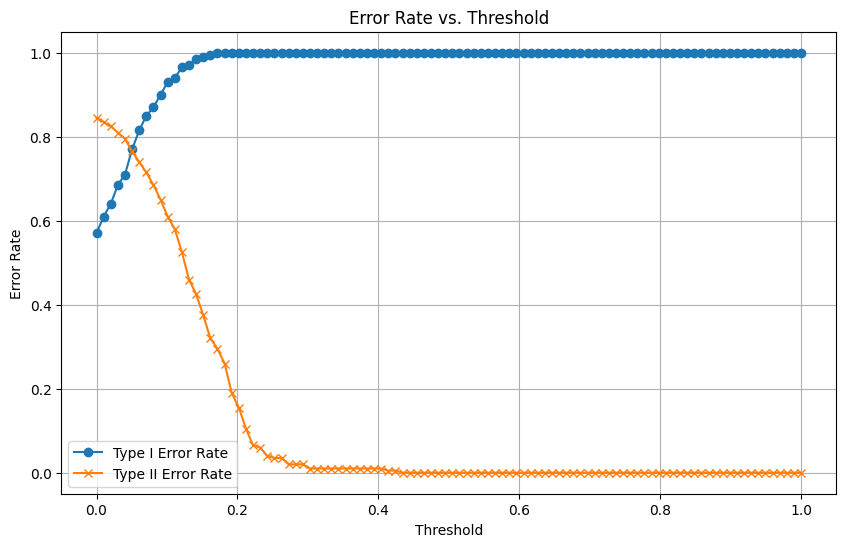

In [23]:
def calculateLDA(X1, X0):

  # Zscore normalize both labels
  mu1 = np.mean(X1, axis=0)
  mu0 = np.mean(X0, axis=0)
  std1 = np.std(X1, axis=0, ddof=1)
  std0 = np.std(X0, axis=0, ddof=1)
  zX1 = (X1 - mu1) / std1
  zX0 = (X0 - mu0) / std0

  # Calculate the covariance matrix which when zscore standardized is also the within-class scatter matrix
  sw1 = np.cov(zX1, rowvar=False)
  sw0 = np.cov(zX0, rowvar=False)
  sw = sw1 + sw0

  # Calculate the between class scatter matrix
  mudiff = (mu1 - mu0)
  sb = np.outer(mudiff, mudiff)

  eigenvalues, eigenvectors = np.linalg.eigh(np.linalg.inv(sw) @ sb)
  # print(eigenvalues)
  # print(eigenvectors)

  # Sort the eigenvalues and eigenvectors in descending order
  idx = np.argsort(eigenvalues)[::-1]
  eigenvalues = eigenvalues[idx]
  eigenvectors = eigenvectors[:, idx]

  # Calculate w
  # w = np.linalg.inv(sw) @ (mu1 - mu0)

  return eigenvectors[:, 0]

# Setup k-fold validation where k = 5
k = 5

# Randomly shuffle both the approved and denied subsets
td_approved = training_data_approved.sample(frac=1)
td_denied = training_data_denied.sample(frac=1)
# print(td_approved.head())

# Split data from each subset into k folds by the indices
approved_folds = np.split(td_approved.to_numpy(), k)
denied_folds = np.split(td_denied.to_numpy(), k)
# print(approved_folds[0])

# Store the vector (w) for each fold in a list
w_list = []

# Calculate the vector (w) for each fold
for i in range(k):
  test_fold = approved_folds[i] + denied_folds[i]
  train_fold_X1 = np.concatenate([approved_folds[j] for j in range(k) if j != i], axis=0)
  train_fold_X0 = np.concatenate([denied_folds[j] for j in range(k) if j != i], axis=0)
  # Feed each fold into the LDA function
  w_list.append(calculateLDA(train_fold_X1[:, :-1], train_fold_X0[:, :-1]))

# Get the final vector (w) by averaging all of the (w) vectors
w = np.mean(w_list, axis=0)
# print(w)

# Testing LDA Thresholds
def testLDA(testing_data_std, w, threshold):
  incorrect_approvals = 0
  incorrect_denials = 0

  for index, row in testing_data_std.iterrows():
    label = int(row['LoanApproved'])
    features = row.iloc[:-1].to_numpy()
    proj = np.dot(features, w)
    # print(proj)
    if proj > threshold:
      if label == 0:
        incorrect_approvals += 1
    elif proj <= threshold:
      if label == 1:
        incorrect_denials += 1

  return incorrect_approvals / 200, incorrect_denials / 200

# Zscore normalize the testing data
testing_data_std = testing_data.copy()
for column in testing_data_std.columns:
  if column != 'LoanApproved':
    testing_data_std[column] = testing_data_std[column].astype(float)
testing_data_std.iloc[:, :-1] = (testing_data_std.iloc[:, :-1] - testing_data_std.iloc[:, :-1].mean()) / testing_data_std.iloc[:, :-1].std()
# print(testing_data_std.head())

# Choose granularity of thresholds
thresholds = np.linspace(0, 1, 100)
type1_error_rates = []
type2_error_rates = []

for threshold in thresholds:
  a, b = testLDA(testing_data_std, w, threshold)
  type1_error_rates.append(b)
  type2_error_rates.append(a)

# print(type1_error_rates)
# print(type2_error_rates)
# Plotting the error rates against the thresholds
plt.figure(figsize=(10, 6))
plt.plot(thresholds, type1_error_rates, marker='o', label='Type I Error Rate')
plt.plot(thresholds, type2_error_rates, marker='x', label='Type II Error Rate')
plt.title('Error Rate vs. Threshold')
plt.xlabel('Threshold')
plt.ylabel('Error Rate')
plt.grid()
plt.legend()
plt.show()

## Decision Tree
Either use a built-in function or design your own question at each decision node using Gini Impurity or Information Gain.

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Standardize the training data
X = training_data.iloc[:, :-1]
y = training_data.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the training and testing data
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

# Train a decision tree classifier on the standardized training data
clf = DecisionTreeClassifier()
clf.fit(X_train_std, y_train)

# Standardize the testing data using the same scaler
testing_data_std = testing_data.copy()
for column in testing_data_std.columns:
  if column != 'LoanApproved':
    testing_data_std[column] = testing_data_std[column].astype(float)
testing_data_std.iloc[:, :-1] = scaler.transform(testing_data_std.iloc[:, :-1])


# Iterate over each row of the testing set, classify it, and tally the type 1 and type 2 errors
errorst1 = 0
errorst2 = 0
for index, row in testing_data_std.iterrows():
  label = int(row['LoanApproved'])
  features = row.iloc[:-1].to_numpy()
  prediction = clf.predict([features])[0]
  if prediction == 0 and label == 1:
    errorst1 += 1
  elif prediction == 1 and label == 0:
    errorst2 += 1

print("Type 1 Error Rate:", errorst1 / 200)
print("Type 2 Error Rate:", errorst2 / 200)

Type 1 Error Rate: 0.195
Type 2 Error Rate: 0.145


### Decision Tree Algorithm
I decided to use a library implmentation. The DecisionTreeClassifier in sklearn.tree uses CART and since I did not specify for it to work with entropy it splits using Gini Impurity by default.

## k-Nearest Neighbors
Evaluate the performance of kNN algorithm for k =  1, 3, 5, 10.

In [25]:
def kNN(k, X_train, y_train, test_row):

  # Calculate the Euclidean distance of all the training data against the row
  distances = np.sqrt(np.sum((X_train - test_row)**2, axis=1))

  # Get the indices of the k closest neighbors from the list of distances
  k_indices = np.argsort(distances)[:k]

  # Get the labels of the the k closest neighbors (Just 1's and 0's)
  k_labels = y_train[k_indices]

  k_labels = k_labels.astype(int)

  # return the majority label
  return np.bincount(k_labels).argmax()

# Preprocess the rows into features and labels
X_train = training_data.iloc[:, :-1].to_numpy()
y_train = training_data.iloc[:, -1].to_numpy()

# Store the results for 1, 3, 5, 10 kNN -> the format is [type 1 error rate, type 2 error rate]
knn_1 = [0,0]
knn_3 = [0,0]
knn_5 = [0,0]
knn_10 = [0,0]

# Iterate through each row in test data
for index, row in testing_data.iterrows():
  test_row = row.iloc[:-1].to_numpy()
  label = row['LoanApproved']
  for k in [1, 3, 5, 10]:
    predicted_label = kNN(k, X_train, y_train, test_row)
    match k:
      case 1:
        if label == 0 and predicted_label == 1:
          knn_1[1] += 1
        elif label == 1 and predicted_label == 0:
          knn_1[0] += 1
      case 3:
        if label == 0 and predicted_label == 1:
          knn_3[1] += 1
        elif label == 1 and predicted_label == 0:
          knn_3[0] += 1
      case 5:
        if label == 0 and predicted_label == 1:
          knn_5[1] += 1
        elif label == 1 and predicted_label == 0:
          knn_5[0] += 1
      case 10:
        if label == 0 and predicted_label == 1:
          knn_10[1] += 1
        elif label == 1 and predicted_label == 0:
          knn_10[0] += 1

# Print the results
print("1 Nearest Neighbor:")
print("Type 1 Error Rate:", knn_1[0] / 200)
print("Type 2 Error Rate:", knn_1[1] / 200, "\n")
print("3 Nearest Neighbors:")
print("Type 1 Error Rate:", knn_3[0] / 200)
print("Type 2 Error Rate:", knn_3[1] / 200, "\n")
print("5 Nearest Neighbors:")
print("Type 1 Error Rate:", knn_5[0] / 200)
print("Type 2 Error Rate:", knn_5[1] / 200, "\n")
print("10 Nearest Neighbors:")
print("Type 1 Error Rate:", knn_10[0] / 200)
print("Type 2 Error Rate:", knn_10[1] / 200, "\n")

1 Nearest Neighbor:
Type 1 Error Rate: 0.185
Type 2 Error Rate: 0.25 

3 Nearest Neighbors:
Type 1 Error Rate: 0.17
Type 2 Error Rate: 0.185 

5 Nearest Neighbors:
Type 1 Error Rate: 0.135
Type 2 Error Rate: 0.2 

10 Nearest Neighbors:
Type 1 Error Rate: 0.165
Type 2 Error Rate: 0.17 



## Support Vector Machine
The training data is not linearly separable, so use a soft margin SVM. Either use a builtin function and provide the optimization in the documentation or design your own and provide the objective function.

In [32]:
from sklearn.svm import SVC

# Zscore standardize the training data
# Split the training data into training and testing sets
X = (training_data.iloc[:, :-1] - training_data.iloc[:, :-1].mean()) / training_data.iloc[:, :-1].std()
y = training_data.iloc[:, -1]
# print(X.shape)
# print(y.shape)

# Create and train the SVM model
model = SVC(kernel="linear", C=3.75)  # Using a linear kernel
model.fit(X.to_numpy(), y.to_numpy())

# Standardize the testing data
testing_data_std = testing_data.copy()
for column in testing_data_std.columns:
  if column != 'LoanApproved':
    testing_data_std[column] = testing_data_std[column].astype(float)
testing_data_std.iloc[:, :-1] = (testing_data_std.iloc[:, :-1] - testing_data_std.iloc[:, :-1].mean()) / testing_data_std.iloc[:, :-1].std()

# Loop through each row of the testing data
type1_error_rate = 0
type2_error_rate = 0
for index, row in testing_data_std.iterrows():
  test_row = row.iloc[:-1].values.reshape(1, -1)
  label = row['LoanApproved']
  predicted_label = model.predict(test_row)
  if label == 0 and predicted_label == 1:
    type2_error_rate += 1
  elif label == 1 and predicted_label == 0:
    type1_error_rate += 1

print("Type 1 Error Rate:", type1_error_rate/200)
print("Type 2 Error Rate:", type2_error_rate/200)

Type 1 Error Rate: 0.035
Type 2 Error Rate: 0.095


### SVM Algorithm
SVC stands for Support Vector Classification and while it offers multiple different kernels to to map and split data I decided to stick to what we learned. I used a linear kernel and since the data is not linearly separable the (C) parameter allows for soft margin like a cost function. The underlying fit is done through solving a quadratic optimization problem taking into account the cost (C) that we provide it. (As for optimizing C, I ended just trying a bunch of values to get the best one)

# Part 2 - PCA Binary Classifiers


## Find the Principal Components

In [27]:
# Cross validate the PCA with k-fold validation
k = 5

# Randomly shuffle the training data
td = training_data.sample(frac=1)

# Split data from each subset into k folds by the indices
folds = np.split(td.to_numpy(), k)

# Store the covariance matrix for each fold in a list
cov_list = []

# Normalize then calculate the covariance matrix for each fold
for i in range(k):
  test_fold = folds[i]
  train_fold = np.concatenate([folds[j] for j in range(k) if j != i], axis=0)
  train_fold[:, :-1] = (train_fold[:, :-1] - train_fold[:, :-1].mean(axis=0)) / train_fold[:, :-1].std(axis=0, ddof=1)
  cov_list.append(np.cov(train_fold[:, :-1], rowvar=False))

# Average the covariance matrices
cov = np.mean(cov_list, axis=0)

# Calculate the eigenvalues and eigvectors
eigenvalues, eigenvectors = np.linalg.eigh(cov)

# Sort the eigenvalues and eigenvectors in descending order
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Create 3 new datasets using the first 5, 10, and 15 principal components

# Separate Label column
feature_train = training_data.iloc[:, :-1]
label_train = training_data.iloc[:, -1]
feature_test = testing_data.iloc[:, :-1]
label_test = testing_data.iloc[:, -1]

# Normalize the feature vectors (both test and training are normalized with training mean and std.dev.)
train_mean = feature_train.mean()
train_std = feature_train.std()
feature_train = (feature_train - train_mean) / train_std
feature_test = (feature_test - train_mean) / train_std

# Apply first 5 principal components
feature_train_5 = np.dot(feature_train, eigenvectors[:, :5])
feature_test_5 = np.dot(feature_test, eigenvectors[:, :5])
# Apply first 10 principal components
feature_train_10 = np.dot(feature_train, eigenvectors[:, :10])
feature_test_10 = np.dot(feature_test, eigenvectors[:, :10])
# Apply first 15 principal components
feature_train_15 = np.dot(feature_train, eigenvectors[:, :15])
feature_test_15 = np.dot(feature_test, eigenvectors[:, :15])

# Combine the new feature sets back with their labels
training_data_5 = np.concatenate((feature_train_5, label_train.to_numpy().reshape(-1, 1)), axis=1)
training_data_10 = np.concatenate((feature_train_10, label_train.to_numpy().reshape(-1, 1)), axis=1)
training_data_15 = np.concatenate((feature_train_15, label_train.to_numpy().reshape(-1, 1)), axis=1)
testing_data_5 = np.concatenate((feature_test_5, label_test.to_numpy().reshape(-1, 1)), axis=1)
testing_data_10 = np.concatenate((feature_test_10, label_test.to_numpy().reshape(-1, 1)), axis=1)
testing_data_15 = np.concatenate((feature_test_15, label_test.to_numpy().reshape(-1, 1)), axis=1)
# print(training_data_5[:5])
# print(training_data_10.shape)
# print(testing_data_15.shape)

## k-Nearest Neighbor
Design 3 kNN classifiers using 5, 10, and 15 principal components.

In [28]:
# The same as before, find k = 1, 3, 5, 10 for each PCA dataset 5, 10, and 15

def testkNN(pca_data_training, pca_data_testing):

  # Store the results for 1, 3, 5, 10 kNN -> the format is [type 1 error rate, type 2 error rate]
  knn_1 = [0,0]
  knn_3 = [0,0]
  knn_5 = [0,0]
  knn_10 = [0,0]

  # Iterate through each row in test data
  for row in pca_data_testing:
    test_row = row[:-1]
    label = row[-1]
    for k in [1, 3, 5, 10]:
      predicted_label = kNN(k, pca_data_training[:, :-1], pca_data_training[:, -1], test_row)

      # This is just to tally type 1 and type 2 errors
      match k:
        case 1:
          if label == 0 and predicted_label == 1:
            knn_1[1] += 1
          elif label == 1 and predicted_label == 0:
            knn_1[0] += 1
        case 3:
          if label == 0 and predicted_label == 1:
            knn_3[1] += 1
          elif label == 1 and predicted_label == 0:
            knn_3[0] += 1
        case 5:
          if label == 0 and predicted_label == 1:
            knn_5[1] += 1
          elif label == 1 and predicted_label == 0:
            knn_5[0] += 1
        case 10:
          if label == 0 and predicted_label == 1:
            knn_10[1] += 1
          elif label == 1 and predicted_label == 0:
            knn_10[0] += 1

  return [knn_1, knn_3, knn_5, knn_10]

pca5_results = testkNN(training_data_5, testing_data_5)
pca10_results = testkNN(training_data_10, testing_data_10)
pca15_results = testkNN(training_data_15, testing_data_15)

def printResults(results, pca):
  # Print the results
  print(pca, "Principal Components:")
  print("\t1 Nearest Neighbor:")
  print("\t\tType 1 Error Rate:", results[0][0] / 200)
  print("\t\tType 2 Error Rate:", results[0][1] / 200)
  print("\t3 Nearest Neighbors:")
  print("\t\tType 1 Error Rate:", results[1][0] / 200)
  print("\t\tType 2 Error Rate:", results[1][1] / 200)
  print("\t5 Nearest Neighbors:")
  print("\t\tType 1 Error Rate:", results[2][0] / 200)
  print("\t\tType 2 Error Rate:", results[2][1] / 200)
  print("\t10 Nearest Neighbors:")
  print("\t\tType 1 Error Rate:", results[3][0] / 200)
  print("\t\tType 2 Error Rate:", results[3][1] / 200, "\n")

printResults(pca5_results, "5")
printResults(pca10_results, "10")
printResults(pca15_results, "15")

5 Principal Components:
	1 Nearest Neighbor:
		Type 1 Error Rate: 0.155
		Type 2 Error Rate: 0.205
	3 Nearest Neighbors:
		Type 1 Error Rate: 0.105
		Type 2 Error Rate: 0.165
	5 Nearest Neighbors:
		Type 1 Error Rate: 0.1
		Type 2 Error Rate: 0.18
	10 Nearest Neighbors:
		Type 1 Error Rate: 0.1
		Type 2 Error Rate: 0.15 

10 Principal Components:
	1 Nearest Neighbor:
		Type 1 Error Rate: 0.205
		Type 2 Error Rate: 0.245
	3 Nearest Neighbors:
		Type 1 Error Rate: 0.135
		Type 2 Error Rate: 0.22
	5 Nearest Neighbors:
		Type 1 Error Rate: 0.12
		Type 2 Error Rate: 0.2
	10 Nearest Neighbors:
		Type 1 Error Rate: 0.14
		Type 2 Error Rate: 0.145 

15 Principal Components:
	1 Nearest Neighbor:
		Type 1 Error Rate: 0.18
		Type 2 Error Rate: 0.24
	3 Nearest Neighbors:
		Type 1 Error Rate: 0.15
		Type 2 Error Rate: 0.23
	5 Nearest Neighbors:
		Type 1 Error Rate: 0.12
		Type 2 Error Rate: 0.265
	10 Nearest Neighbors:
		Type 1 Error Rate: 0.145
		Type 2 Error Rate: 0.195 



### Comparison to kNN in Part 1
Comparing the type 1 and type 2 error rates to kNN in Part 1 it would seem that the PCA 5 kNN made fewer mistakes, while the 10 and 15 PCA while slightly lower seems to be about the same as Part 1. It would seem that as you include more Principal Components that explain less and less of the variance, the smaller the returns we get from using them.

## Suppor Vector Machine
Design 3 SVM classifiers using 5, 10 and 15 principal components.

In [29]:
# Design 3 SVM classifiers using 5, 10 and 15 principal components.

def testSVM(training_data_pca, testing_data_pca):
  X_train_pca = training_data_pca[:, :-1]
  y_train_pca = training_data_pca[:, -1]
  X_test_pca = testing_data_pca[:, :-1]
  y_test_pca = testing_data_pca[:, -1]

  # Create and train the SVM model
  model_pca = SVC(kernel="linear", C=3.75)  # Using a linear kernel
  model_pca.fit(X_train_pca, y_train_pca)

  # Loop through each row of the testing data adding up type 1 and type 2 errors
  type1_error_rate = 0
  type2_error_rate = 0
  for i in range(len(X_test_pca)):
    test_row = X_test_pca[i].reshape(1, -1)
    label = y_test_pca[i]
    predicted_label = model_pca.predict(test_row)
    if label == 0 and predicted_label == 1:
      type2_error_rate += 1
    elif label == 1 and predicted_label == 0:
      type1_error_rate += 1

  return type1_error_rate / 200, type2_error_rate / 200

# Directly return the type 1 and type 2 error rates
type1_5, type2_5 = testSVM(training_data_5, testing_data_5)
type1_10, type2_10 = testSVM(training_data_10, testing_data_10)
type1_15, type2_15 = testSVM(training_data_15, testing_data_15)

print("SVM with 5 principal components:")
print("Type 1 Error Rate:", type1_5)
print("Type 2 Error Rate:", type2_5)

print("\nSVM with 10 principal components:")
print("Type 1 Error Rate:", type1_10)
print("Type 2 Error Rate:", type2_10)

print("\nSVM with 15 principal components:")
print("Type 1 Error Rate:", type1_15)
print("Type 2 Error Rate:", type2_15)

SVM with 5 principal components:
Type 1 Error Rate: 0.075
Type 2 Error Rate: 0.135

SVM with 10 principal components:
Type 1 Error Rate: 0.035
Type 2 Error Rate: 0.165

SVM with 15 principal components:
Type 1 Error Rate: 0.03
Type 2 Error Rate: 0.145
